# Pyramidal InAs quantum dot in GaAs (Pryor benchmark geometry)

Square-based pyramid with **{101} side facets** (so height = base/2 is fixed by the facet
choice, and a single parameter `base` sets the size), no wetting layer -- the exact island
geometry of **C. Pryor, *Phys. Rev. B* 57, 7190 (1998)** (free at arXiv:cond-mat/9710304,
Fig. 1 there), chosen so results can be compared against that paper's one-band and
eight-band benchmark energies. Default size below is Pryor's canonical comparison island,
**b = 14 nm** (base 14 nm, height 7 nm).

**What matches Pryor and what deliberately doesn't (yet):** the geometry matches exactly;
everything else is *our* existing system -- our material parameters (Vurgaftman-based, with
the aestimo-derived band offsets) and the Davies uniform-trace strain. Two known,
documented differences follow from that choice:

1. **Well depth / parameterization**: with our parameters the strain-shifted conduction well
   is ~125 meV deep (flat); Pryor's full anisotropic strain solve gives a well tapering from
   ~400 meV at the base to ~270 meV at the tip, with his 85 meV unstrained valence-band
   offset convention. Consequently our electron is only a few meV bound where his one-band
   calculation gets ~110 meV. A true replication run would swap in his Table I parameter set
   -- the natural next step, kept separate so parameter effects aren't conflated with
   geometry effects.
2. **Piezoelectric term**: Pryor includes the strain-induced piezoelectric potential, which
   breaks the pyramid's C4 symmetry to C2 and splits his near-degenerate excited pair by a
   few meV. We omit it, so our p-like pairs should be degenerate to solver precision.

The strain treatment itself (Tr(strain) uniform inside, zero outside, any shape) is the
Davies J. Appl. Phys. 84, 1358 (1998) characteristic-function result -- see
`qdsolver_core.trace_strain_from_mask`.

In [1]:
import sys, os, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qdsolver_core as qd

## Structure parameters -- edit these and re-run

`h = 0.7` nm makes the b = 14 nm base exactly 20 cells wide, so the base edges and apex land
exactly on grid planes; if you change `base`, keep `base/h` an integer (and `pad` a multiple
of `h`) to avoid the grid-alignment artifacts characterized in the convergence notebook.
Pryor's size sweep covers b = 6-18 nm.

In [2]:
matrix_mat, dot_mat = qd.MATERIALS['GaAs'], qd.MATERIALS['InAs']

base = 14.0   # pyramid base side (nm); height = base/2 is fixed by the {101} facets
h = 0.7       # grid spacing (nm)
pad = 8.4     # matrix padding beyond base edges / below base / above apex (nm)

cx = np.arange(-(base / 2 + pad), (base / 2 + pad) + 1e-9, h)
cz = np.arange(-pad, base / 2 + pad + 1e-9, h)
X, Y, Z = np.meshgrid(cx, cx, cz, indexing='ij')
print(f"grid {X.shape} = {X.size:,} points; pyramid height = {base/2:.1f} nm")

grid (45, 45, 35) = 70,875 points; pyramid height = 7.0 nm


## Geometry + volume sanity check

Analytic pyramid volume is $b^2 (b/2)/3$. The voxel count comes out ~15% **high** at
h = 0.7 (opposite sign from the lens's staircasing deficit): the z = 0 voxel layer straddles
the base plane and counts its full thickness. Refine `h` if absolute volume matters.

In [3]:
inside = qd.pyramid_mask(X, Y, Z, base)

vol_numeric = inside.sum() * h**3
vol_analytic = base**2 * (base / 2) / 3
print(f"voxel volume {vol_numeric:.1f} nm^3 vs analytic {vol_analytic:.1f} nm^3 "
      f"(ratio {vol_numeric/vol_analytic:.3f})")

voxel volume 528.2 nm^3 vs analytic 457.3 nm^3 (ratio 1.155)


## Strain and material fields

In [4]:
eps_star = qd.eigenstrain(dot_mat['a0'], matrix_mat['a0'])
nu = qd.voigt_poisson_ratio(matrix_mat['C11'], matrix_mat['C12'], matrix_mat['C44'])
trace_strain, trace_inside = qd.trace_strain_from_mask(inside, eps_star, nu)

m_e_field = np.where(inside, dot_mat['m_e'], matrix_mat['m_e'])
m_h_field = np.where(inside, dot_mat['m_h'], matrix_mat['m_h'])
V_e = np.where(inside, dot_mat['fi_e'], matrix_mat['fi_e']) + dot_mat['Ac'] * trace_strain
V_h = np.where(inside, dot_mat['fi_h'], matrix_mat['fi_h']) + dot_mat['Av'] * trace_strain

print(f"lattice mismatch {eps_star*100:.2f}%, Tr(strain) inside = {trace_inside:.4f}")
print(f"electron well: dot floor {(dot_mat['fi_e']+dot_mat['Ac']*trace_inside)*1e3:.1f} meV, "
      f"GaAs barrier {matrix_mat['fi_e']*1e3:.1f} meV "
      f"(flat, {(matrix_mat['fi_e']-dot_mat['fi_e']-dot_mat['Ac']*trace_inside)*1e3:.0f} meV deep; "
      f"Pryor's tapers ~400 -> ~270 meV)")
print(f"hole well:     dot ceiling {(dot_mat['fi_h']+dot_mat['Av']*trace_inside)*1e3:.1f} meV, "
      f"GaAs barrier {matrix_mat['fi_h']*1e3:.1f} meV")

lattice mismatch -6.69%, Tr(strain) inside = -0.1078
electron well: dot floor 799.8 meV, GaAs barrier 924.5 meV (flat, 125 meV deep; Pryor's tapers ~400 -> ~270 meV)
hole well:     dot ceiling -255.8 meV, GaAs barrier -497.8 meV


## Solve, with checks

- **Binding**: which states are genuinely below the GaAs barrier (confined) vs box states?
  With our parameters, expect only the electron *ground* state to be (weakly) bound at
  b = 14 -- structurally consistent with Pryor's unstrained-mass one-band case, which also
  finds a single bound conduction state, though his is ~110 meV deep.
- **C4 near-degeneracy**: the p_x/p_y pair should be degenerate to solver tolerance (we omit
  the piezoelectric term that splits Pryor's by 2-6 meV).

In [5]:
t0 = time.time()
E_e, psi_e = qd.solve_states(m_e_field, V_e, h, n_states=4, hole=False)
E_h, psi_h = qd.solve_states(m_h_field, V_h, h, n_states=4, hole=True)
print(f"solved in {time.time()-t0:.1f} s")

print(f"\nGROUND STATES: E_e0 = {E_e[0]*1e3:.2f} meV, E_h0 = {E_h[0]*1e3:.2f} meV")
print("(energy zero = this project's aestimo-convention band alignment; Pryor's figures")
print(" reference the GaAs valence-band edge instead, so shift by "
      f"{-matrix_mat['fi_h']*1e3:.1f} meV to compare absolute values)")

print(f"\nE_e (meV): {np.round(E_e*1e3, 2)}")
print(f"E_h (meV): {np.round(E_h*1e3, 2)}")

n_bound_e = int(np.sum(E_e < matrix_mat['fi_e']))
print(f"\nbound electron states: {n_bound_e} "
      f"(ground state {(matrix_mat['fi_e']-E_e[0])*1e3:.1f} meV below the GaAs barrier; "
      f"states above {matrix_mat['fi_e']*1e3:.1f} meV are box states, not dot states)")
print(f"hole ground state {(E_h[0]-matrix_mat['fi_h'])*1e3:.1f} meV above the GaAs VB barrier")
print(f"hole p_x/p_y splitting: {abs(E_h[2]-E_h[1])*1e3:.4f} meV (piezo omitted -> ~0)")

transition = E_e[0] - E_h[0]
print(f"\nnaive transition energy: {transition*1e3:.1f} meV ({1239.84/transition:.0f} nm)")
print("(no electron-hole Coulomb attraction; use schrodinger_poisson.self_consistent_exciton")
print(" for the corrected value -- Pryor's Fig. 5 Hartree binding at b=14 is ~22 meV)")

solved in 28.9 s

GROUND STATES: E_e0 = 916.90 meV, E_h0 = -292.88 meV
(energy zero = this project's aestimo-convention band alignment; Pryor's figures
 reference the GaAs valence-band edge instead, so shift by 497.8 meV to compare absolute values)

E_e (meV): [916.9  958.07 958.14 968.66]
E_h (meV): [-292.88 -316.53 -316.53 -335.48]

bound electron states: 1 (ground state 7.6 meV below the GaAs barrier; states above 924.5 meV are box states, not dot states)
hole ground state 204.9 meV above the GaAs VB barrier
hole p_x/p_y splitting: 0.0000 meV (piezo omitted -> ~0)

naive transition energy: 1209.8 meV (1025 nm)
(no electron-hole Coulomb attraction; use schrodinger_poisson.self_consistent_exciton
 for the corrected value -- Pryor's Fig. 5 Hartree binding at b=14 is ~22 meV)


## Ground-state densities in the x-z plane (through the pyramid center)

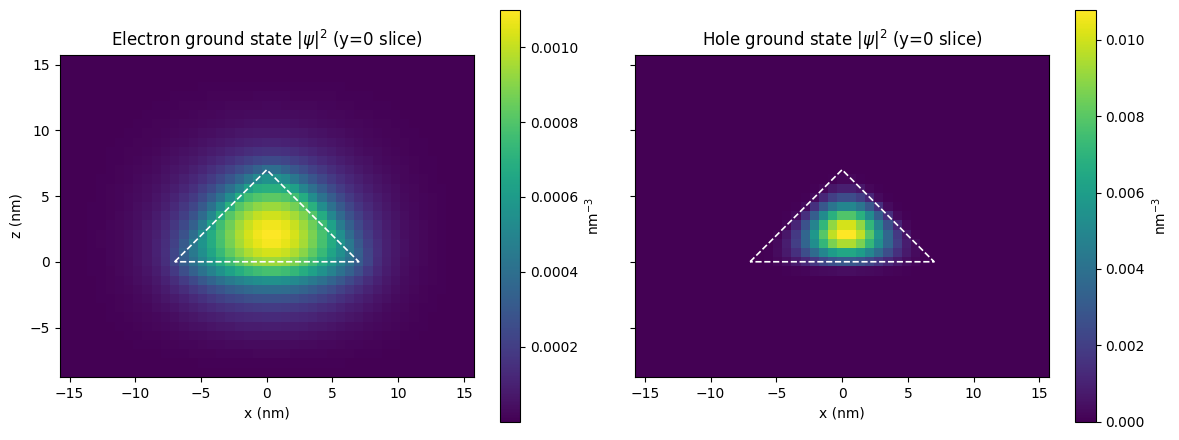

In [6]:
Nx, Ny, Nz = X.shape
mid_y = Ny // 2
dens_e = (psi_e[:, 0]**2).reshape(X.shape)[:, mid_y, :]
dens_h = (psi_h[:, 0]**2).reshape(X.shape)[:, mid_y, :]

# pyramid silhouette through the center plane: triangle (-b/2,0) -> (0,b/2) -> (b/2,0)
tri_x = [-base/2, 0, base/2, -base/2]
tri_z = [0, base/2, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, dens, label in zip(axes, [dens_e, dens_h], ["Electron", "Hole"]):
    im = ax.pcolormesh(cx, cz, dens.T, shading='auto', cmap='viridis')
    ax.plot(tri_x, tri_z, 'w--', lw=1.2)
    ax.set_xlabel("x (nm)")
    ax.set_title(f"{label} ground state $|\\psi|^2$ (y=0 slice)")
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, label="nm$^{-3}$")
axes[0].set_ylabel("z (nm)")
fig.tight_layout()

## Band-edge line cuts: vertical (through the apex axis) and lateral (through the base)

These are the direct analogues of Pryor's Fig. 2a/2b -- except his strain-modified band
edges vary within the island (CB well 400 meV deep at the base tapering to 270 meV at the
tip, valence band peaked near tip and base), while our uniform-trace approximation gives
flat wells. That comparison is the clearest picture of what the Davies approximation
keeps and what it discards.

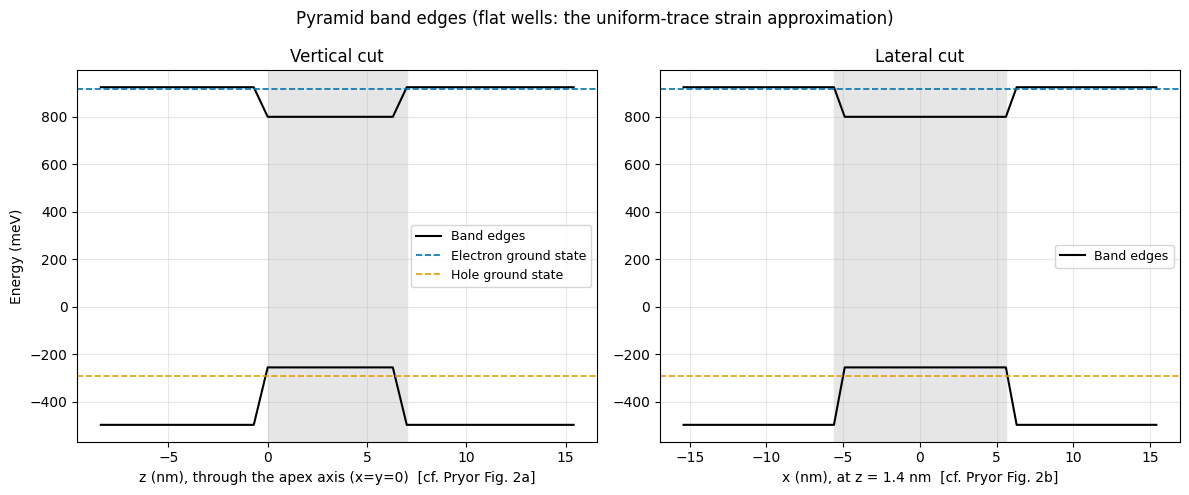

In [7]:
mid_x = Nx // 2
iz_cut = np.argmin(np.abs(cz - base / 8))  # lateral cut low in the pyramid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(cz, V_e[mid_x, mid_y, :] * 1e3, color="black", lw=1.5, label="Band edges")
ax.plot(cz, V_h[mid_x, mid_y, :] * 1e3, color="black", lw=1.5)
ax.axhline(E_e[0] * 1e3, color="#0072B2", ls="--", lw=1.2, label="Electron ground state")
ax.axhline(E_h[0] * 1e3, color="#E69F00", ls="--", lw=1.2, label="Hole ground state")
ax.axvspan(0, base / 2, color="0.9", zorder=0)
ax.set_xlabel("z (nm), through the apex axis (x=y=0)  [cf. Pryor Fig. 2a]")
ax.set_ylabel("Energy (meV)")
ax.set_title("Vertical cut")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(cx, V_e[:, mid_y, iz_cut] * 1e3, color="black", lw=1.5, label="Band edges")
ax.plot(cx, V_h[:, mid_y, iz_cut] * 1e3, color="black", lw=1.5)
ax.axhline(E_e[0] * 1e3, color="#0072B2", ls="--", lw=1.2)
ax.axhline(E_h[0] * 1e3, color="#E69F00", ls="--", lw=1.2)
half_width = base / 2 - cz[iz_cut]
ax.axvspan(-half_width, half_width, color="0.9", zorder=0)
ax.set_xlabel(f"x (nm), at z = {cz[iz_cut]:.1f} nm  [cf. Pryor Fig. 2b]")
ax.set_title("Lateral cut")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Pyramid band edges (flat wells: the uniform-trace strain approximation)")
fig.tight_layout()

## Toward a true Pryor replication

With geometry now identical, the remaining gap to Pryor's one-band numbers (his ~110 meV
electron binding vs our few meV) is parameterization, not shape. The replication checklist:

1. **Swap in Pryor's Table I parameters** as an alternate materials dict: unstrained VBO
   E_vbo = 85 meV (his band-alignment convention, replacing our `Band_offset` construction),
   a_c = -6.66/-9.3 eV, a_v = 0.66/0.7 eV, masses 0.023/0.0665 m0, eps_R = 15.15 everywhere.
2. Compare against his one-band cases at b = 14 nm: single bound conduction state near
   1.41 eV above the GaAs VB edge (unstrained masses), E1-E0 = 110 meV for the m_eff = 0.04 m0
   and m(r) variants.
3. Run the exciton loop (`schrodinger_poisson`) against his Hartree Fig. 5: binding 27 meV at
   b = 9 nm to ~18 meV at b = 18 nm. He notes Hartree exciton binding is insensitive to the
   Hamiltonian (it depends mainly on the charge densities), so this is the benchmark where
   our model should agree best.
4. Residual differences then isolate the physics we knowingly omit: the tapering (vs flat)
   strain well, and the piezoelectric C4 -> C2 splitting.